**19 - Aprendizado por Reforço**

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/fabiobento/dnn-course-2026-1/blob/main/19_reinforcement_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/fabiobento/dnn-course-2026-1/blob/main/19_reinforcement_learning.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Configuração do Notebook

Verificar se temos Python

In [1]:
import sys

assert sys.version_info >= (3, 10)

Verificar se está utilizando o Google Colab ou o Kaggle

In [2]:
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

Se estiver usando o Colab, as bibliotecas Box2D e Stable-Baselines3 não vêm pré-instaladas, portanto devemos instalá-las manualmente. No Kaggle, o Box2D também não está pré-instalado; já o Stable-Baselines3 e o gymnasium estão pré-instalados, porém são versões muito antigas, então precisamos atualizá-los.

In [3]:
if IS_COLAB:
    %pip uninstall -qy gym
    %pip install -qU Box2D stable_baselines3

if IS_KAGGLE:
    %pip uninstall -qy gym
    %pip install -qU gymnasium
    %pip install -qU Box2D stable_baselines3

Também precisamos de PyTorch ≥ 2.6.0:

In [4]:
from packaging.version import Version
import torch

assert Version(torch.__version__) >= Version("2.6.0")

Este notebook pode ser muito lento para executar sem um acelerador de hardware, então, se conseguirmos encontrar um, vamos usá-lo:

In [5]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cuda'

Vamos emitir um aviso se não houver um acelerador de hardware disponível:

In [6]:
if device == "cpu":
    print("Redes neurais podem ser muito lentas sem um acelerador de hardware.")
    if IS_COLAB:
        print("Vá em Ambiente de execução > Alterar o tipo de ambiente de execução e selecione um acelerador de hardware GPU.")
    if IS_KAGGLE:
        print("Vá em Configurações > Acelerador e selecione GPU.")

Vamos definir os tamanhos de fonte padrão para deixar as figuras mais bonitas. Como este notebook contém animações, também importamos `matplotlib.animation` e configuramos as animações para usar JS+HTML.

In [7]:
import matplotlib.animation
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rc('animation', html='jshtml')

Por fim, vamos carregar a extensão tensorboard, que usaremos na seção sobre PPO logo abaixo.

In [8]:
%load_ext tensorboard

# Introdução

O aprendizado por reforço (RL - *Reinforcement Learning*) é um dos campos de aprendizado de máquina que tem recebido mais atenção recentemente, e também um dos mais antigos. Ele existe desde a década de 1950, produzindo muitas aplicações interessantes ao longo dos anos, particularmente em jogos (por exemplo, TD-Gammon, um programa que joga gamão) e no controle de máquinas, mas raramente chegando às manchetes dos jornais. No entanto, uma revolução ocorreu em 2013, quando pesquisadores de uma startup britânica chamada DeepMind demonstraram um sistema que poderia [aprender a jogar quase qualquer jogo do Atari do zero](https://arxiv.org/abs/1312.5602), eventualmente superando os humanos4 na maioria deles, usando apenas pixels brutos como entradas e sem nenhum conhecimento prévio das regras dos jogos.5 Este foi o primeiro de uma série de feitos incríveis:

*   Em 2016, o AlphaGo da DeepMind derrotou Lee Sedol, um lendário jogador profissional do jogo de Go; e em 2017, derrotou Ke Jie, o campeão mundial. Nenhum programa jamais havia chegado perto de derrotar um mestre deste jogo, muito menos os melhores.
*   Em 2020, a DeepMind lançou o AlphaFold, que pode prever a forma 3D de proteínas com uma precisão sem precedentes. Isso é um divisor de águas na biologia, química e medicina. De fato, Demis Hassabis (fundador e CEO) e John Jumper (diretor) receberam o Prêmio Nobel de Química pelo AlphaFold.
*   Em 2022, a DeepMind lançou o AlphaCode, que pode gerar código em um nível de programação competitiva.
*   Em 2023, a DeepMind lançou o GNoME, que pode prever novas estruturas cristalinas, incluindo centenas de milhares de materiais estáveis previstos.

Então, como os pesquisadores da DeepMind conseguiram tudo isso? Bem, eles aplicaram o poder do aprendizado profundo (*deep learning*) ao campo do aprendizado por reforço, e funcionou além de suas maiores expectativas: nascia assim o aprendizado por reforço profundo (*deep reinforcement learning*). Hoje, embora a DeepMind continue liderando o caminho, muitas outras organizações se juntaram à área, e todo o campo está fervilhando com novas ideias e uma ampla gama de aplicações.

Nesta aula, primeiro explicarei o que é o aprendizado por reforço e no que ele é bom, para então apresentar três das famílias de técnicas mais importantes no aprendizado por reforço profundo: gradientes de política (*policy gradients*), redes Q profundas (*deep Q-networks* - incluindo uma discussão sobre processos de decisão de Markov) e, por fim, métodos ator-crítico (*actor-critic*), incluindo o popular PPO, que usaremos para vencer um jogo do Atari.

# O que é Aprendizado por Reforço

No aprendizado por reforço, um agente de software faz observações e realiza ações dentro de um ambiente e, em troca, recebe recompensas do ambiente. Seu objetivo é aprender a agir de forma a maximizar suas recompensas esperadas ao longo do tempo. Se você não se importa com um pouco de antropomorfismo, pode pensar nas recompensas positivas como prazer e nas recompensas negativas como dor (o termo "recompensa" é um pouco enganoso neste caso). Em resumo, o agente atua no ambiente e aprende por tentativa e erro a maximizar seu prazer e minimizar sua dor.

Esta é uma configuração bastante ampla que pode se aplicar a uma grande variedade de tarefas. Aqui estão alguns exemplos (veja a [Figura 19-1](#figure-19-1)):

*   O agente pode ser o programa que controla um robô. Neste caso, o ambiente é o mundo real, o agente observa o ambiente através de um conjunto de sensores, como câmeras e sensores de toque, e suas ações consistem em enviar sinais para ativar os motores. Ele pode ser programado para obter recompensas positivas sempre que se aproximar do destino alvo e recompensas negativas sempre que perder tempo ou for na direção errada.
*   O agente pode ser o programa que controla a Ms. Pac-Man. Neste caso, o ambiente é uma simulação do jogo de Atari, as ações são as nove posições possíveis do joystick (canto superior esquerdo, para baixo, centro e assim por diante), as observações são capturas de tela e as recompensas são apenas os pontos do jogo.
*   Da mesma forma, o agente pode ser o programa jogando um jogo de tabuleiro como o Go. Ele só recebe uma recompensa se vencer.
* O agente não precisa controlar algo que se move fisicamente (ou virtualmente). Por exemplo, pode ser um termostato inteligente, que recebe recompensas positivas sempre que se aproxima da temperatura alvo e economiza energia, e recompensas negativas quando os humanos precisam ajustar a temperatura, de modo que o agente deve aprender a antecipar as necessidades humanas.
* O agente pode observar os preços do mercado de ações e decidir quanto comprar ou vender a cada segundo. As recompensas são, obviamente, os ganhos e perdas monetárias.

Note que pode não haver absolutamente nenhuma recompensa positiva; por exemplo, o agente pode se mover em um labirinto, recebendo uma recompensa negativa a cada passo de tempo, então é melhor que ele encontre a saída o mais rápido possível! Existem muitos outros exemplos de tarefas para as quais o aprendizado por reforço é bem adequado, como carros autônomos, sistemas de recomendação, colocação de anúncios em uma página da web ou o controle de onde um sistema de classificação de imagens deve focar sua atenção.

<a id="figure-19-1"></a>
![](https://github.com/fabiobento/dnn-course-2026-1/raw/main/images/figure-19-1.png)

**Figura 19-1 - Exemplos de Aprendizado por Reforço: (a) robótica, (b) Ms. Pac-Man, (c) Jogador de Go
, (d) termostato, (e) operador automático de mercado de ações(*trader*).** ([Fonte](https://ageron.github.io/))

# Policy Gradients

O algoritmo que um agente de software usa para determinar suas ações é chamado de sua política(*policy*). A política pode ser qualquer algoritmo que você possa imaginar, como uma rede neural que recebe observações como entradas e produz a ação a ser tomada (veja a [Figura 19-2](#figure-19-2)).

<a id="figure-19-2"></a>
![](https://github.com/fabiobento/dnn-course-2026-1/raw/main/images/figure-19-2.png)

**Figura 19-2 - Aprendizado por reforço usando uma política de rede neural(*neural network policy*).** ([Fonte](https://ageron.github.io/))

A política nem precisa ser determinística. De fato, em alguns casos, ela nem precisa observar o ambiente, desde que possa obter recompensas! Por exemplo, considere um aspirador de pó robótico cego cuja recompensa é a quantidade de poeira que ele coleta em 30 minutos. Sua política poderia ser mover-se para frente com alguma probabilidade *p* a cada segundo, ou girar aleatoriamente para a esquerda ou direita com probabilidade 1 – *p*. O ângulo de rotação seria um ângulo aleatório entre –*r* e +*r*. Como essa política envolve alguma aleatoriedade, ela é chamada de **política estocástica**. O robô terá uma trajetória errática, o que garante que ele eventualmente chegará a qualquer lugar que possa alcançar e pegará toda a poeira. A questão é: quanta poeira ele pegará em 30 minutos?

Como você treinaria esse robô? Existem apenas dois parâmetros de política que você pode ajustar: a probabilidade *p* e a faixa de ângulo *r*. Um possível algoritmo de aprendizado poderia ser testar muitos valores diferentes para esses parâmetros e escolher a combinação com o melhor desempenho (veja a Figura 19-3). Este é um exemplo de **pesquisa de política** (*policy search*), neste caso usando uma abordagem de força bruta. Quando o espaço de política é muito grande (o que geralmente é o caso), encontrar um bom conjunto de parâmetros dessa maneira é como procurar uma agulha em um palheiro gigantesco.

Outra maneira de explorar o espaço de políticas é usar algoritmos genéticos. Por exemplo, você poderia criar aleatoriamente uma primeira geração de 100 políticas e testá-las, depois "matar" as 80 piores políticas e fazer com que os 20 sobreviventes produzam 4 descendentes cada. Um descendente é uma cópia de seu progenitor mais alguma variação aleatória. As políticas sobreviventes mais seus descendentes juntos constituem a segunda geração. Você pode continuar iterando pelas gerações dessa maneira até encontrar uma boa política.
> Observação:
>
>- Em algoritmos genéticos, geralmente é melhor dar aos indivíduos que têm baixo desempenho uma pequena chance de sobrevivência, para preservar alguma diversidade no 'pool genético'."
>- Se houver um único progenitor, isso é chamado de reprodução assexuada. Com dois (ou mais) progenitores, chama-se reprodução sexuada. O genoma de um descendente (neste caso, um conjunto de parâmetros de política) é composto aleatoriamente por partes dos genomas de seus progenitores.

<a id="figure-19-3"></a>
![](https://github.com/fabiobento/dnn-course-2026-1/raw/main/images/figure-19-3.png)

**Figura 19-3 - Quatro pontos no espaço de políticas (esquerda) e o comportamento correspondente do agente (direita).** ([Fonte](https://ageron.github.io/))

Ainda outra abordagem é usar técnicas de otimização avaliando os gradientes das recompensas em relação aos parâmetros da política e, em seguida, ajustar esses parâmetros seguindo os gradientes em direção a recompensas maiores. Algoritmos que seguem essa estratégia são conhecidos como algoritmos de gradiente de política (PG - *Policy Gradient*). Mas antes que possamos implementá-los, primeiro precisamos criar um ambiente para o agente viver — então é hora de apresentar a biblioteca Gymnasium.

> Observação:
>
> Algoritmos como *Policy Gradient* são é chamado do tipo de ascensão de gradiente. É exatamente como o gradiente descendente, mas na direção oposta: maximizando em vez de minimizar.

## Introdução ao Gymnasium Library

Um dos desafios do aprendizado por reforço é que, para treinar um agente, primeiro você precisa ter um ambiente de trabalho. Se você quiser programar um agente que aprenderá a jogar um jogo de Atari, precisará de um simulador de jogos de Atari. Se você quiser programar um robô que anda, então o ambiente é o mundo real, e você pode treinar seu robô diretamente nesse ambiente. No entanto, isso tem seus limites: se o robô cair de um penhasco, você não pode simplesmente clicar em Desfazer (*Undo*). Você também não pode acelerar o tempo — adicionar mais poder de computação não fará o robô se mover mais rápido — e geralmente é muito caro treinar 1.000 robôs em paralelo. Em resumo, o treinamento é difícil e lento no mundo real, portanto, você geralmente precisa de um ambiente simulado pelo menos para o treinamento inicial (*bootstrap*). Por exemplo, você pode usar uma biblioteca como PyBullet ou MuJoCo para simulação física em 3D.

A biblioteca Gymnasium é um kit de ferramentas de código aberto que fornece uma ampla variedade de ambientes simulados (jogos de Atari, jogos de tabuleiro, simulações físicas em 2D e 3D, e assim por diante), que você pode usar para treinar agentes, compará-los ou desenvolver novos algoritmos de RL. É a sucessora do OpenAI Gym e agora é mantida por uma comunidade de pesquisadores e desenvolvedores.

O Gymnasium vem pré-instalado no Colab, juntamente com a biblioteca Arcade Learning Environment (ALE) `ale_py`, que é um emulador para jogos de Atari 2600 e é necessária para todos os ambientes Atari, bem como a biblioteca Box2D, necessária para vários ambientes com física 2D. Se você estiver programando em sua própria máquina em vez do Colab, e tiver seguido as instruções de instalação em https://homl.info/install-p, então você deve estar pronto para começar.

Vamos começar importando o Gymnasium e criando um ambiente:

In [9]:
import gymnasium as gym

env = gym.make("CartPole-v1", render_mode="rgb_array", max_episode_steps=1000)

Aqui, nós criamos um ambiente CartPole (versão 1). Esta é uma simulação 2D na qual um carrinho pode ser acelerado para a esquerda ou para a direita com o objetivo de equilibrar um poste colocado em cima dele (veja a [Figura 19-4](#figure-19-4)) — uma tarefa clássica de controle. Explicarei `render_mode` e `max_episode_steps` em breve.

<a id="figure-19-4"></a>
![](https://github.com/fabiobento/dnn-course-2026-1/raw/main/images/figure-19-4.png)

**Figura 19-4 - O ambiente CartPole.** ([Fonte](https://ageron.github.io/))

O dicionário `gym.envs.registry` contém os nomes e especificações de todos os ambientes disponíveis. Você pode exibir uma lista formatada com `gym.pprint_registry()`. Os ambientes Atari só estarão disponíveis quando iniciarmos o emulador ALE.

In [10]:
# Exibir alguns dos ambientes
envs = gym.envs.registry
sorted(envs.keys())[:5] + ["..."]

['Acrobot-v1', 'Ant-v2', 'Ant-v3', 'Ant-v4', 'Ant-v5', '...']

In [11]:
# Mostra a especificação do ambiente CartPole-v1

envs["CartPole-v1"]

EnvSpec(id='CartPole-v1', entry_point='gymnasium.envs.classic_control.cartpole:CartPoleEnv', reward_threshold=475.0, nondeterministic=False, max_episode_steps=500, order_enforce=True, disable_env_checker=False, kwargs={}, namespace=None, name='CartPole', version=1, additional_wrappers=(), vector_entry_point='gymnasium.envs.classic_control.cartpole:CartPoleVectorEnv')

In [12]:
gym.pprint_registry()

===== classic_control =====
Acrobot-v1             CartPole-v0            CartPole-v1
MountainCar-v0         MountainCarContinuous-v0 Pendulum-v1
===== phys2d =====
phys2d/CartPole-v0     phys2d/CartPole-v1     phys2d/Pendulum-v0
===== box2d =====
BipedalWalker-v3       BipedalWalkerHardcore-v3 CarRacing-v3
LunarLander-v3         LunarLanderContinuous-v3
===== toy_text =====
Blackjack-v1           CliffWalking-v1        CliffWalkingSlippery-v1
FrozenLake-v1          FrozenLake8x8-v1       Taxi-v3
===== tabular =====
tabular/Blackjack-v0   tabular/CliffWalking-v0
===== None =====
Ant-v2                 Ant-v3                 GymV21Environment-v0
GymV26Environment-v0   HalfCheetah-v2         HalfCheetah-v3
Hopper-v2              Hopper-v3              Humanoid-v2
Humanoid-v3            HumanoidStandup-v2     InvertedDoublePendulum-v2
InvertedPendulum-v2    Pusher-v2              Reacher-v2
Swimmer-v2             Swimmer-v3             Walker2d-v2
Walker2d-v3
===== mujoco =====
Ant-v4    

Após o ambiente ser criado, você deve inicializá-lo usando o método `reset()`, especificando opcionalmente uma semente aleatória. Isso retorna a primeira observação. As observações dependem do tipo de ambiente. Para o ambiente CartPole, cada observação é um array NumPy contendo quatro *floats* que representam a posição horizontal do carrinho (0.0 = centro), sua velocidade (positivo significa para a direita), o ângulo do poste (0.0 = vertical) e sua velocidade angular (positivo significa no sentido horário). O método `reset()` também retorna um dicionário que pode conter informações extras específicas do ambiente. Isso pode ser útil para depuração e, às vezes, para treinamento. Por exemplo, em muitos ambientes do Atari, ele contém o número de vidas restantes. No entanto, no ambiente CartPole, este dicionário está vazio:

In [13]:
obs, info = env.reset(seed=42)
obs

array([ 0.0273956 , -0.00611216,  0.03585979,  0.0197368 ], dtype=float32)

In [14]:
info

{}

Vamos chamar o método `render()` para renderizar este ambiente como uma imagem. Como definimos `render_mode="rgb_array"` ao criar o ambiente, a imagem será retornada como um array NumPy (você pode então usar a função `imshow()` do Matplotlib para exibir esta imagem):

In [15]:
img = env.render()
# formato da imagem: altura, largura, canais (3 = Vermelho, Verde, Azul)
img.shape

/home/fabio/Documentos/vscode/ml-dl/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


(400, 600, 3)

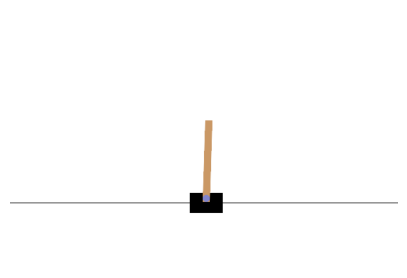

In [16]:
# cria uma pequena função para renderizar e plotar um ambiente

def plot_environment(env, figsize=(5, 4)):
    plt.figure(figsize=figsize)
    img = env.render() # renderiza a imagem do ambiente
    plt.imshow(img)    # exibe a imagem
    plt.axis("off")    # remove os eixos (coordenadas) do gráfico
    return img

plot_environment(env)
plt.show()

Agora vamos perguntar ao ambiente quais ações são possíveis:

In [17]:
env.action_space

Discrete(2)

`Discrete(2)` significa que são os inteiros 0 e 1, os quais representam esquerda ou direita. Outros ambientes podem ter açoes discretas adicionais, ou outros tipos de ações (contínua, por exemplo).

Como o poste está se inclinando para a direita(`obs[2]>0`), vamos acelerar o cart para a direita:

In [18]:
action = 1  # acelerar para a direita
obs, reward, done, truncated, info = env.step(action)
obs

array([ 0.02727336,  0.18847767,  0.03625453, -0.26141977], dtype=float32)

O método `step()` executa a ação desejada e retorna cinco valores:

* **`obs`**: Esta é a nova observação. O carrinho agora está se movendo para a direita (`obs > 0`). O poste ainda está inclinado para a direita (`obs > 0`), mas sua velocidade angular agora é negativa (`obs < 0`), então ele provavelmente estará inclinado para a esquerda após o próximo passo.
* **`reward`**: Neste ambiente, você recebe uma recompensa (*reward*) de 1.0 a cada passo, não importa o que faça, então o objetivo é manter o episódio em execução pelo maior tempo possível. Um episódio é uma execução do ambiente até que o jogo termine ou seja interrompido.
* **`done`**: Este valor será `True` quando o episódio terminar. Isso acontecerá quando o poste se inclinar muito ou sair da tela. Depois disso, o ambiente deve ser reinicializado antes de poder ser usado novamente.
* **`truncated`**: Este valor será `True` quando um episódio for interrompido precocemente, tipicamente por um *wrapper* de ambiente que impõe um número máximo de passos por episódio (veja a documentação do Gymnasium para mais detalhes sobre *wrappers* de ambiente). Por padrão, a especificação do ambiente para o CartPole define o número máximo de passos como 500, mas nós mudamos isso para 1.000 quando criamos o ambiente. Alguns algoritmos de aprendizado por reforço tratam episódios truncados de forma diferente de episódios finalizados normalmente (ou seja, quando `done` é `True`), mas neste capítulo os trataremos de forma idêntica.
* **`info`**: Este dicionário específico do ambiente pode fornecer informações extras, assim como o retornado pelo método `reset()`.

In [19]:
reward, done, truncated, info

(1.0, False, False, {})


Depois de terminar de usar um ambiente — possivelmente após muitos episódios — você deve chamar seu método `close()` para liberar os recursos.

In [20]:
if done or truncated:
    obs, info = env.reset()

### Uma policy simples "*hard-coded*"

Vamos codificar uma política simples que acelera para a esquerda quando o poste está se inclinando para a esquerda e acelera para a direita quando o poste está se inclinando para a direita. Vamos executar essa política para ver as recompensas médias que ela obtém ao longo de 500 episódios:

In [21]:
def basic_policy(obs):
    angle = obs[2]
    # vai para a esquerda se estiver inclinado para a esquerda, caso contrário, vai para a direita
    return 0 if angle < 0 else 1

totals = []
for episode in range(500):
    total_rewards = 0
    obs, info = env.reset(seed=episode)
    while True:  # sem risco de loop infinito: será truncado após 1000 passos
        action = basic_policy(obs)
        obs, reward, done, truncated, info = env.step(action)
        total_rewards += reward
        # interrompe se o episódio terminar (falha) ou se for truncado (limite de tempo)
        if done or truncated:
            break

    totals.append(total_rewards)

Este código é autoexplicativo. Vamos dar uma olhada no resultado:```

In [22]:
import numpy as np

np.mean(totals), np.std(totals), min(totals), max(totals)

(np.float64(41.698), np.float64(8.389445512070509), 24.0, 63.0)

Mesmo com 500 tentativas, essa política nunca conseguiu manter o poste na vertical por mais de 63 passos consecutivos. Nada ótimo. Se você observar a simulação no notebook deste capítulo, verá que o carrinho oscila para a esquerda e para a direita cada vez com mais força, até que o poste se incline demais. Uma rede neural pode fazer melhor!

Vamos visualizar um episódio. Você pode aprender sobre animações no Matplotlib  [notebook com tutorial sobre o Matplotlib](https://github.com/fabiobento/dnn-course-2026-1/blob/main/tools_matplotlib.ipynb).

In [23]:
# Essa célula mostra a animação de um episódio

def update_scene(num, frames, patch):
    # Atualiza o conteúdo da imagem para o quadro atual da animação
    patch.set_data(frames[num])
    return patch,

def plot_animation(frames, repeat=False, interval=40):
    fig = plt.figure()
    patch = plt.imshow(frames[0])
    plt.axis('off') # Oculta os eixos para uma visualização limpa
    # Cria a animação usando a biblioteca matplotlib
    anim = matplotlib.animation.FuncAnimation(
        fig, update_scene, fargs=(frames, patch),
        frames=len(frames), repeat=repeat, interval=interval)
    plt.close() # Fecha a figura para evitar que o Matplotlib exiba um gráfico estático extra
    return anim

def show_one_episode(policy, seed=42):
    frames = []
    # Cria o ambiente definindo o modo de renderização para array de pixels (RGB)
    env = gym.make("CartPole-v1", render_mode="rgb_array",
                   max_episode_steps=1000)
    obs, info = env.reset(seed=seed)
    while True:
        frames.append(env.render()) # Captura o quadro atual do ambiente
        action = policy(obs)        # Escolhe a ação baseada na política fornecida
        obs, reward, done, truncated, info = env.step(action)
        if done or truncated:
            break
    env.close() # Fecha o ambiente para liberar recursos
    return plot_animation(frames)

# Executa e exibe a animação de um episódio usando a política básica definida anteriormente
show_one_episode(basic_policy)

Claramente o sistema é instável e, após apenas algumas oscilações, o poste acaba ficando inclinado demais.

## Neural Network Policies

Vamos criar uma política de rede neural. Essa rede neural receberá uma observação como entrada e produzirá a ação a ser executada, assim como a política que codificamos (*hardcoded*) anteriormente. Mais precisamente, ela estimará uma probabilidade para cada ação e, em seguida, selecionará uma ação aleatoriamente, de acordo com as probabilidades estimadas (veja a Figura 19-5). No caso do ambiente CartPole, existem apenas duas ações possíveis (esquerda ou direita), então precisamos de apenas um neurônio de saída. Ele produzirá a probabilidade *p* da ação 1 (direita) e, naturalmente, a probabilidade da ação 0 (esquerda) será 1 – *p*. Por exemplo, se a saída for 0,7, escolheremos a ação 1 com 70% de probabilidade, ou a ação 0 com 30% de probabilidade (esta é uma distribuição de Bernoulli com *p* = 0,7).

<a id="figure-19-5"></a>
![](https://github.com/fabiobento/dnn-course-2026-1/raw/main/images/figure-19-5.png)

**Figura 19-5 - *Neural network policy*.** ([Fonte](https://ageron.github.io/))

Você pode se perguntar por que estamos escolhendo uma ação aleatória com base nas probabilidades dadas pela rede neural, em vez de simplesmente escolher a ação com a pontuação mais alta. Essa abordagem permite que o agente encontre o equilíbrio certo entre explorar novas ações e explorar (*exploiting*) as ações que já se sabe que funcionam bem. Aqui está uma analogia: suponha que você vá a um restaurante pela primeira vez e todos os pratos pareçam igualmente atraentes, então você escolhe um aleatoriamente. Se acabar sendo bom, você pode aumentar a probabilidade de pedi-lo na próxima vez, mas não deve aumentar essa probabilidade para 100%, ou você nunca experimentará os outros pratos, alguns dos quais podem ser ainda melhores do que o que você experimentou. Esse dilema exploração/explotação (*exploration/exploitation dilemma*) é central no aprendizado por reforço.

Observe também que, neste ambiente específico, as ações e observações passadas podem ser ignoradas com segurança, já que cada observação contém o estado completo do ambiente. Se houvesse algum estado oculto, você talvez precisasse considerar as ações e observações passadas também. Por exemplo, se o ambiente revelasse apenas a posição do carrinho, mas não sua velocidade, você teria que considerar não apenas a observação atual, mas também a observação anterior para estimar a velocidade atual. Outro exemplo é quando as observações possuem ruído; nesse caso, geralmente deseja-se usar as últimas observações para estimar o estado atual mais provável. O problema do CartPole é, portanto, o mais simples possível; as observações são livres de ruído e contêm o estado completo do ambiente.

Vamos usar o PyTorch para implementar uma política de rede neural básica para o CartPole:

In [24]:
import torch
import torch.nn as nn

class PolicyNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(4, 5), nn.ReLU(), nn.Linear(5, 1))

    def forward(self, state):
        return self.net(state)

Nossa rede de política é um MLP minúsculo, já que é uma tarefa bastante simples. O número de entradas é o tamanho do estado do ambiente: no caso do CartPole, é apenas o tamanho de uma única observação, que é quatro. Temos apenas uma camada oculta com cinco unidades (não há necessidade de mais neste caso). Finalmente, queremos produzir uma única probabilidade, então temos um único neurônio de saída. Se houvesse mais de duas ações possíveis, haveria um neurônio de saída por ação em vez disso. Por questões de desempenho e estabilidade numérica, não adicionamos uma função sigmoide no final, de modo que a rede na verdade produzirá logits em vez de probabilidades.

Em seguida, vamos definir uma função que usará essa rede de política para escolher uma ação:

In [25]:
def choose_action(model, obs):
    state = torch.as_tensor(obs)
    logit = model(state)
    dist = torch.distributions.Bernoulli(logits=logit)
    action = dist.sample()
    log_prob = dist.log_prob(action)
    return int(action.item()), log_prob

A função recebe uma única observação, converte-a em um tensor e a passa para a rede de política para obter o logit para a ação 1 (direita). Em seguida, ela cria uma distribuição de probabilidade de Bernoulli com esse logit e amostra uma ação a partir dela: essa distribuição produzirá 1 (direita) com probabilidade *p* = exp(logit) / (1 + exp(logit)) e 0 (esquerda) com probabilidade 1 – *p*. Se houvesse mais de duas ações possíveis, você usaria uma distribuição Categórica (*Categorical*) em vez disso. Por fim, calculamos a probabilidade logarítmica (*log probability*) da ação amostrada (ou seja, log(*p*) ou log(1 – *p*)): essa probabilidade logarítmica será necessária mais tarde para o treinamento.


> Observação
>
> Se o espaço de ação for contínuo, você pode usar uma distribuição Gaussiana em vez de uma distribuição de Bernoulli ou categórica. Em vez de prever logits, a rede de política deve prever a média e o desvio padrão (ou o log do desvio padrão) da distribuição. O log do desvio padrão é frequentemente cortado (*clipped*) para garantir que a distribuição não seja muito ampla nem muito estreita.

In [26]:
# código extra – uma função que cria uma animação para um determinado modelo de política

# Define a semente aleatória do PyTorch para garantir reprodutibilidade
torch.manual_seed(42)

# Instancia a rede neural de política e a coloca em modo de avaliação (desativa dropout, etc.)
model = PolicyNetwork()
model.eval()

def neural_net_policy(obs):
    # Desativa o cálculo de gradientes para economizar memória e processamento durante a inferência
    with torch.no_grad():
        # Escolhe uma ação com base no modelo e na observação atual
        action, _ = choose_action(model, obs)
        return action

# Exibe a animação de um episódio completo utilizando a política da rede neural
show_one_episode(neural_net_policy)

OK, agora temos uma política de rede neural que pode receber um estado do ambiente (neste caso, uma única observação) e escolher uma ação. Mas como a treinamos?

## REINFORCE

### Avaliando Ações: O Problema da Atribuição de Crédito(*The Credit Assignment Problem*)

Se soubéssemos qual era a melhor ação em cada passo, poderíamos treinar a rede neural como de costume, minimizando a entropia cruzada entre a distribuição de probabilidade estimada e a distribuição de probabilidade alvo. Seria apenas um aprendizado supervisionado regular. No entanto, no aprendizado por reforço, a única orientação que o agente recebe é através de recompensas, e as recompensas são tipicamente esparsas e atrasadas. Por exemplo, se o agente consegue equilibrar o poste por um total de 100 passos, como ele pode saber quais das 100 ações que tomou foram boas e quais foram ruins? Tudo o que ele sabe é que o poste caiu após a última ação, mas certamente essa última ação não é totalmente responsável. Isso é chamado de **problema de atribuição de crédito** (*credit assignment problem*): quando o agente recebe uma recompensa (ou uma penalidade), é difícil para ele saber quais ações devem ser creditadas (ou culpadas) por isso. Pense em um cachorro que é recompensado horas depois de ter se comportado bem; ele entenderá pelo que está sendo recompensado?

Para simplificar a atribuição de crédito, uma estratégia comum é avaliar uma ação com base na soma de todas as recompensas que vêm depois dela, aplicando um fator de desconto, $\gamma$ (gama), a cada passo. Essa soma de recompensas descontadas é chamada de **retorno** da ação. Considere o exemplo na [Figura 19-6](#figura-19-6). Se um agente decide ir para a direita três vezes seguidas e obtém uma recompensa de +10 após o primeiro passo, 0 após o segundo passo e, finalmente, –50 após o terceiro passo, então, assumindo que usamos um fator de desconto $\gamma = 0.8$, a primeira ação terá um retorno de $10 + \gamma \times 0 + \gamma^2 \times (–50) = –22$.

<a id="figure-19-6"></a>
![](https://github.com/fabiobento/dnn-course-2026-1/raw/main/images/figure-19-6.png)

**Figura 19-6 - *Calculando o retorno de uma ação: a soma das recompensas futuras descontadas*.** ([Fonte](https://ageron.github.io/))

A função a seguir calcula os retornos, dados as recompensas e o fator de desconto:

In [ ]:
def compute_returns(rewards, discount_factor):
    # Cria uma cópia da lista de recompensas para não modificar a original
    returns = rewards[:]  
    
    # Percorre a lista de trás para frente (do último passo até o segundo)
    for step in range(len(returns) - 1, 0, -1):
        # O retorno do passo anterior é a recompensa atual somada ao 
        # retorno do passo seguinte multiplicado pelo fator de desconto
        returns[step - 1] += returns[step] * discount_factor

    # Converte a lista final de retornos em um tensor do PyTorch
    return torch.tensor(returns)

A função produz esse resultado:

In [28]:
compute_returns([10, 0, -50], discount_factor=0.8)

tensor([-22., -40., -50.])

Se o fator de desconto estiver próximo de 0, então as recompensas futuras não contarão muito em comparação com as recompensas imediatas. Por outro lado, se o fator de desconto estiver próximo de 1, as recompensas muito no futuro contarão quase tanto quanto as recompensas imediatas. Fatores de desconto típicos variam de 0,9 a 0,99. Com um fator de desconto de 0,95, recompensas 13 passos no futuro contam aproximadamente pela metade do valor das recompensas imediatas (já que $0,95^{13} \approx 0,5$), enquanto que com um fator de desconto de 0,99, recompensas 69 passos no futuro contam pela metade das recompensas imediatas. No ambiente CartPole, as ações têm efeitos de curto prazo, então escolher um fator de desconto baixo de 0,95 parece razoável e ajudará com a atribuição de crédito, tornando o treinamento mais rápido e mais estável. No entanto, se o fator de desconto for definido como muito baixo, o agente aprenderá uma estratégia subótima, focando demais em ganhos de curto prazo.

Agora que temos uma maneira de avaliar cada ação, estamos prontos para treinar nosso primeiro agente usando gradientes de política. Vamos ver como.

### Resolvendo o problema do CartPole usando Policy Gradients

Como discutido anteriormente, os algoritmos de gradiente de política otimizam os parâmetros de uma política seguindo os gradientes em direção a recompensas maiores. Um algoritmo PG popular, chamado **REINFORCE** (ou PG de Monte Carlo), foi [introduzido em 1992 por Ronald Williams](https://people.cs.umass.edu/~barto/courses/cs687/williams92simple.pdf). Ele tem muitas variantes, com vários ajustes, mas o princípio geral é este:

1. Primeiro, deixe a política da rede neural jogar o jogo por um episódio e registre as recompensas e as probabilidades logarítmicas estimadas.
2. Em seguida, calcule o retorno de cada ação, usando a função definida na seção anterior.
3. Se o retorno de uma ação for positivo, significa que a ação provavelmente foi boa, e você quer tornar essa ação ainda mais provável de ser escolhida no futuro. Por outro lado, se o retorno de uma ação for negativo, você quer tornar essa ação menos provável. Para conseguir isso, você pode minimizar a perda REINFORCE definida na Equação 19-1: isso maximizará as recompensas descontadas esperadas.

**Equação 19-1. Perda REINFORCE**

$$\mathcal{L}_\theta = -\sum_t \log \pi_\theta(a_t|s_t) \cdot r_t$$

Nesta equação, $\pi_\theta(a_t|s_t)$ é a probabilidade estimada da rede de política para a ação $a_t$, dado o estado $s_t$ (onde $t$ é o passo de tempo), e $r_t$ é o retorno observado desta ação; $\theta$ representa os parâmetros do modelo.

Vamos usar o PyTorch para implementar este algoritmo. Primeiro, precisamos de uma função para permitir que a rede de política jogue um episódio e registre as recompensas e as probabilidades logarítmicas:

In [30]:
def run_episode(model, env, seed=None):
    log_probs, rewards = [], []
    obs, info = env.reset(seed=seed)
    while True:  # the environment will truncate the episode if it is too long
        action, log_prob = choose_action(model, obs)
        obs, reward, done, truncated, _info = env.step(action)
        log_probs.append(log_prob)
        rewards.append(reward)
        if done or truncated:
            return log_probs, rewards


A função primeiro reinicializa o ambiente para iniciar um novo episódio. Para reprodutibilidade, passamos uma semente (`seed`) para o método `reset()`. Em seguida, vem o loop do jogo: a cada iteração, passamos o estado atual do ambiente (ou seja, a última observação) para o método `choose_action()` que definimos anteriormente. Ele retorna a ação escolhida e sua probabilidade logarítmica. Em seguida, chamamos o método `step()` do ambiente para executar a ação. Isso retorna uma nova observação (um array NumPy), uma recompensa, dois booleanos indicando se o jogo terminou (`done`) ou foi truncado (`truncated`), e um dicionário `info` (que podemos ignorar com segurança no caso do CartPole). Registramos as probabilidades logarítmicas e as recompensas em duas listas, que retornamos quando o episódio termina.

Podemos finalmente escrever a função de treinamento:

In [31]:
def train_reinforce(model, optimizer, env, n_episodes, discount_factor):
    for episode in range(n_episodes):
        seed = torch.randint(0, 2**32, size=()).item()
        log_probs, rewards = run_episode(model, env, seed=seed)
        returns = compute_returns(rewards, discount_factor)
        std_returns = (returns - returns.mean()) / (returns.std() + 1e-7)
        losses = [-logp * rt for logp, rt in zip(log_probs, std_returns)]
        loss = torch.cat(losses).sum()
        optimizer.zero_grad()        
        loss.backward()
        optimizer.step()
        print(f"\rEpisode {episode + 1}, Reward: {sum(rewards):.2f}", end=" ")

É bem curto e agradável, não é? A cada iteração de treinamento, a função executa um episódio e obtém as probabilidades logarítmicas e as recompensas. Em seguida, ela calcula o retorno de cada ação. Depois, padroniza os retornos (ou seja, subtrai a média dos retornos e divide pelo desvio padrão, mais um pequeno valor para evitar a divisão por zero). Esta etapa de padronização é opcional, mas é um ajuste comum e recomendado para o algoritmo REINFORCE, pois estabiliza o treinamento. A seguir, a função calcula a perda REINFORCE usando a Equação 19-1 e executa um passo do otimizador para minimizar a perda.

É isso, estamos prontos para construir e treinar uma rede de política!

In [32]:
torch.manual_seed(42)
model = PolicyNetwork()
optimizer = torch.optim.NAdam(model.parameters(), lr=0.06)
train_reinforce(model, optimizer, env, n_episodes=200, discount_factor=0.95)

Episode 200, Reward: 131.00  

O treinamento levará menos de um minuto. Se você executar um episódio usando esta rede de política, verá que ela equilibra perfeitamente o poste. Sucesso!

O algoritmo simples de gradientes de política que acabamos de treinar resolveu a tarefa do CartPole, mas não escalaria bem para tarefas maiores e mais complexas. De fato, ele é altamente ineficiente em relação a amostras (*sample inefficient*), o que significa que precisa explorar o jogo por muito tempo antes que possa fazer um progresso significativo. Isso ocorre porque suas estimativas de retorno são extremamente ruidosas, especialmente quando boas ações são misturadas com ruins. No entanto, é a base de algoritmos mais poderosos, como métodos ator-crítico (*actor-critic*), que discutiremos no final deste capítulo.

> **Observação**
>
> Os pesquisadores dessa  área tentam encontrar algoritmos que funcionem bem mesmo quando o agente inicialmente não sabe nada sobre o ambiente. No entanto, a menos que você esteja escrevendo um artigo, você não deve hesitar em injetar conhecimento prévio no agente, pois isso acelerará o treinamento drasticamente. Por exemplo, como você sabe que o poste deve ficar o mais vertical possível, você poderia adicionar recompensas negativas proporcionais ao ângulo do poste. Isso tornará as recompensas muito menos esparsas e acelerará o treinamento. Além disso, se você já tem uma política razoavelmente boa (por exemplo, programada manualmente), você pode querer treinar a rede neural para imitá-la antes de usar gradientes de política para melhorá-la.

Além disso, o algoritmo REINFORCE é bastante instável: o agente pode melhorar por um tempo durante o treinamento, então esquecer tudo de forma catastrófica, aprender novamente, esquecer, aprender, etc. É uma montanha-russa. Isso ocorre em grande parte porque as amostras de treinamento não são independentes e identicamente distribuídas (IID); na verdade, as amostras de treinamento consistem em quaisquer estados que o agente seja capaz de alcançar no momento. Conforme o agente progride, ele explora diferentes partes do ambiente e pode esquecer tudo sobre outras partes. Por exemplo, uma vez que ele aprende a manter o poste na vertical de forma adequada, ele não verá mais postes não verticais e esquecerá totalmente como lidar com eles. E esse problema se agrava muito mais em ambientes mais complexos.

In [33]:
show_one_episode(neural_net_policy)

O aprendizado por reforço é notoriamente difícil, em grande parte devido às instabilidades de treinamento e à [enorme sensibilidade à escolha dos valores dos hiperparâmetros e das sementes aleatórias](https://www.alexirpan.com/2018/02/14/rl-hard.html). Como o pesquisador Andrej Karpathy colocou: "[O aprendizado supervisionado] quer funcionar. [...] O RL deve ser forçado a funcionar". Você precisará de tempo, paciência, perseverança e talvez um pouco de sorte também. Esta é uma das principais razões pelas quais o RL não é tão amplamente adotado quanto o aprendizado profundo regular.

Veremos agora outra família popular de algoritmos: os métodos baseados em valor.

# Extra Material – Markov Chains

The following transition probabilities correspond to the Markov Chain represented in Figure 19–7. Let's run this stochastic process a few times to see what it looks like:

In [33]:
np.random.seed(42)

transition_probabilities = [ # shape=[s, s']
        [0.7, 0.2, 0.0, 0.1],  # from s0 to s0, s1, s2, s3
        [0.0, 0.0, 0.9, 0.1],  # from s1 to s0, s1, s2, s3
        [0.0, 1.0, 0.0, 0.0],  # from s2 to s0, s1, s2, s3
        [0.0, 0.0, 0.0, 1.0]]  # from s3 to s0, s1, s2, s3

n_max_steps = 1000  # to avoid blocking in case of an infinite loop
terminal_states = [3]

def run_chain(start_state):
    current_state = start_state
    for step in range(n_max_steps):
        print(current_state, end=" ")
        if current_state in terminal_states:
            break
        current_state = np.random.choice(
            range(len(transition_probabilities)),
            p=transition_probabilities[current_state]
        )
    else:
        print("...", end="")

    print()

for idx in range(10):
    print(f"Run #{idx + 1}: ", end="")
    run_chain(start_state=0)

Run #1: 0 0 3 
Run #2: 0 1 2 1 2 1 2 1 2 1 3 
Run #3: 0 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 3 
Run #4: 0 3 
Run #5: 0 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 3 
Run #6: 0 1 3 
Run #7: 0 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 3 
Run #8: 0 0 0 1 2 1 2 1 3 
Run #9: 0 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 3 
Run #10: 0 0 0 1 2 1 3 


# Markov Decision Process

Let's define some transition probabilities, rewards and possible actions. For example, in state s0, if action a0 is chosen then with proba 0.7 we will go to state s0 with reward +10, with probability 0.3 we will go to state s1 with no reward, and with never go to state s2 (so the transition probabilities are `[0.7, 0.3, 0.0]`, and the rewards are `[+10, 0, 0]`):

In [34]:
transition_probabilities = [  # shape=[s, a, s']
    [[0.7, 0.3, 0.0], [1.0, 0.0, 0.0], [0.8, 0.2, 0.0]],
    [[0.0, 1.0, 0.0], None, [0.0, 0.0, 1.0]],
    [None, [0.8, 0.1, 0.1], None]
]
rewards = [  # shape=[s, a, s']
    [[+10, 0, 0], [0, 0, 0], [0, 0, 0]],
    [[0, 0, 0], [0, 0, 0], [0, 0, -50]],
    [[0, 0, 0], [+40, 0, 0], [0, 0, 0]]
]
possible_actions = [[0, 1, 2], [0, 2], [1]]

# Q-Value Iteration

In [35]:
Q_values = np.full((3, 3), -np.inf)  # -np.inf for impossible actions
for state, actions in enumerate(possible_actions):
    Q_values[state, actions] = 0.0  # for all possible actions

In [36]:
gamma = 0.90  # the discount factor

history1 = []  # extra code – needed for the figure below
for iteration in range(50):
    Q_prev = Q_values.copy()
    history1.append(Q_prev) # extra code
    for s in range(3):
        for a in possible_actions[s]:
            Q_values[s, a] = np.sum([
                    transition_probabilities[s][a][sp]
                    * (rewards[s][a][sp] + gamma * Q_prev[sp].max())
                for sp in range(3)])

history1 = np.array(history1)  # extra code

In [37]:
Q_values

array([[18.91891892, 17.02702702, 13.62162162],
       [ 0.        ,        -inf, -4.87971488],
       [       -inf, 50.13365013,        -inf]])

In [38]:
Q_values.argmax(axis=1)  # optimal action for each state

array([0, 0, 1])

The optimal policy for this MDP, when using a discount factor of 0.90, is to choose action a0 when in state s0, and choose action a0 when in state s1, and finally choose action a1 (the only possible action) when in state s2. If you try again with a discount factor of 0.95 instead of 0.90, you will find that the optimal action for state s1 becomes a2. This is because the discount factor is larger so the agent values the future more, and it is therefore ready to pay an immediate penalty in order to get more future rewards.

# Q-Learning

Q-Learning works by watching an agent play (e.g., randomly) and gradually improving its estimates of the Q-Values. Once it has accurate Q-Value estimates (or close enough), then the optimal policy consists in choosing the action that has the highest Q-Value (i.e., the greedy policy).

We will need to simulate an agent moving around in the environment, so let's define a function to perform some action and get the new state and a reward:

In [39]:
def step(state, action):
    probas = transition_probabilities[state][action]
    next_state = np.random.choice([0, 1, 2], p=probas)
    reward = rewards[state][action][next_state]
    return next_state, reward

We also need an exploration policy, which can be any policy, as long as it visits every possible state many times. We will just use a random policy, since the state space is very small:

In [40]:
def exploration_policy(state):
    return np.random.choice(possible_actions[state])

Now let's initialize the Q-Values like earlier, and run the Q-Learning algorithm:

In [41]:
# extra code – initializes the Q-Values, just like earlier
np.random.seed(42)
Q_values = np.full((3, 3), -np.inf)
for state, actions in enumerate(possible_actions):
    Q_values[state][actions] = 0

In [42]:
alpha0 = 0.05  # initial learning rate
decay = 0.005  # learning rate decay
gamma = 0.90  # discount factor
state = 0  # initial state
history2 = []  # extra code – needed for the figure below

for iteration in range(10_000):
    history2.append(Q_values.copy())  # extra code
    action = exploration_policy(state)
    next_state, reward = step(state, action)
    next_value = Q_values[next_state].max()  # greedy policy at the next step
    alpha = alpha0 / (1 + iteration * decay)
    Q_values[state, action] *= 1 - alpha
    Q_values[state, action] += alpha * (reward + gamma * next_value)
    state = next_state

history2 = np.array(history2)  # extra code

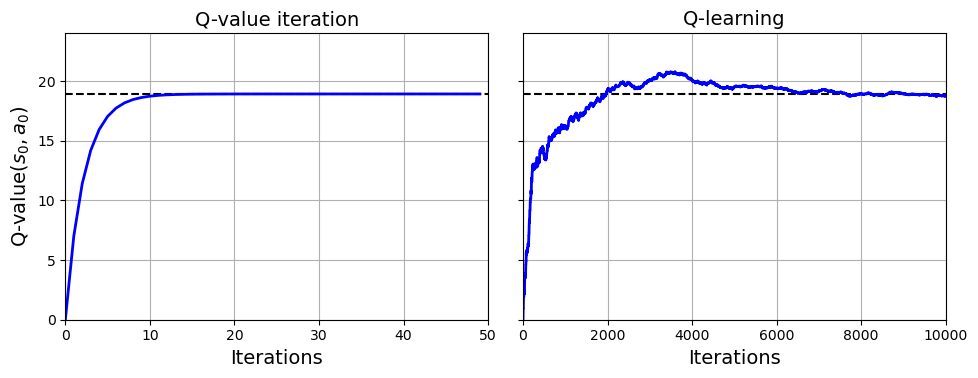

In [43]:
# extra code – this cell generates Figure 19–9

true_Q_value = history1[-1, 0, 0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].set_ylabel("Q-value$(s_0, a_0)$", fontsize=14)
axes[0].set_title("Q-value iteration", fontsize=14)
axes[1].set_title("Q-learning", fontsize=14)
for ax, width, history in zip(axes, (50, 10000), (history1, history2)):
    ax.plot([0, width], [true_Q_value, true_Q_value], "k--")
    ax.plot(np.arange(width), history[:, 0, 0], "b-", linewidth=2)
    ax.set_xlabel("Iterations", fontsize=14)
    ax.axis([0, width, 0, 24])
    ax.grid(True)

plt.show()

# Deep Q-Network

Let's build the DQN. Given a state, it will estimate, for each possible action, the sum of discounted future rewards it can expect after it plays that action (but before it sees its outcome):

In [44]:
class DQN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(4, 32), nn.ReLU(),
                                 nn.Linear(32, 32), nn.ReLU(),
                                 nn.Linear(32, 2))

    def forward(self, state):
        return self.net(state)

In [45]:
def choose_dqn_action(model, obs, epsilon=0.0):
        if torch.rand(()) < epsilon:  # epsilon greedy policy
            return torch.randint(2, size=()).item()
        else:
            state = torch.as_tensor(obs)
            Q_values = model(state)
            return Q_values.argmax().item()  # optimal according to the DQN

We will also need a replay buffer. It will contain the agent's experiences. Each experience will be represented as a tuple with six elements: (state, action, reward, next_state, done, truncated).

Let's also create a function to sample experiences from the replay buffer. It will return a tuple containing a tensor for each of the six fields:

In [46]:
def sample_experiences(replay_buffer, batch_size):
    indices = torch.randint(len(replay_buffer), size=[batch_size])
    batch = [replay_buffer[index] for index in indices.tolist()]
    return [to_tensor([exp[index] for exp in batch]) for index in range(6)]

def to_tensor(data):
    array = np.stack(data)
    dtype = torch.float32 if array.dtype == np.float64 else None
    return torch.as_tensor(array, dtype=dtype)

**Note**: for very large replay buffers (e.g., 100,000 or more), you may want to use a circular buffer instead, as random access time will be O(1) instead of O(N). Or you can check out DeepMind's [Reverb library](https://github.com/deepmind/reverb).

In [47]:
# extra code – A basic circular buffer implementation

class ReplayBuffer:
    def __init__(self, max_length):
        self.data = [None] * max_length
        self.max_length = max_length
        self.index = 0
        self.length = 0

    def append(self, obj):
        self.data[self.index] = obj
        self.length = min(self.length + 1, self.max_length)
        self.index = (self.index + 1) % self.max_length

    def __getitem__(self, index):
        if index < 0 or index >= self.length:
            raise IndexError(f"replay buffer index out of range: {index}")
        return self.data[index]

    def __len__(self):
        return self.length

buff = ReplayBuffer(max_length=4)
for i in range(8):
    buff.append(i)
    print(f"Length: {len(buff)}, data: {buff.data}")

Length: 1, data: [0, None, None, None]
Length: 2, data: [0, 1, None, None]
Length: 3, data: [0, 1, 2, None]
Length: 4, data: [0, 1, 2, 3]
Length: 4, data: [4, 1, 2, 3]
Length: 4, data: [4, 5, 2, 3]
Length: 4, data: [4, 5, 6, 3]
Length: 4, data: [4, 5, 6, 7]


Now we can create a function that will use the DQN to play one step, and record its experience in the replay buffer:

In [48]:
def play_and_record_episode(model, env, replay_buffer, epsilon, seed=None):
    obs, _info = env.reset(seed=seed)
    total_rewards = 0
    model.eval()
    with torch.no_grad():
        while True:
            action = choose_dqn_action(model, obs, epsilon)
            next_obs, reward, done, truncated, _info = env.step(action)
            experience = (obs, action, reward, next_obs, done, truncated)
            replay_buffer.append(experience)
            total_rewards += reward
            if done or truncated:
                return total_rewards
            obs = next_obs

Lastly, let's create a function that will sample some experiences from the replay buffer and perform a training step:

In [49]:
def dqn_training_step(model, optimizer, criterion, replay_buffer, batch_size,
                      discount_factor):
    experiences = sample_experiences(replay_buffer, batch_size)
    state, action, reward, next_state, done, truncated = experiences
    with torch.inference_mode():
        next_Q_value = model(next_state)

    max_next_Q_value, _ = next_Q_value.max(dim=1)
    running = (~(done | truncated)).float()  # 0 if s' is over, 1 if running
    target_Q_value = reward + running * discount_factor * max_next_Q_value
    all_Q_values = model(state)
    Q_value = all_Q_values.gather(dim=1, index=action.unsqueeze(1))
    loss = criterion(Q_value, target_Q_value.unsqueeze(1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

And now, let's train the model!

In [50]:
from collections import deque

def train_dqn(model, env, replay_buffer, optimizer, criterion, n_episodes=800,
              warmup=30, batch_size=32, discount_factor=0.95):
    totals = []
    for episode in range(n_episodes):
        epsilon = max(1 - episode / 500, 0.01)
        seed = torch.randint(0, 2**32, size=()).item()
        total_rewards = play_and_record_episode(model, env, replay_buffer,
                                                epsilon, seed=seed)
        print(f"\rEpisode: {episode + 1}, Rewards: {total_rewards}", end=" ")
        totals.append(total_rewards)
        if episode >= warmup:
            dqn_training_step(model, optimizer, criterion, replay_buffer,
                              batch_size, discount_factor)
    return totals

torch.manual_seed(42)
dqn = DQN()
optimizer = torch.optim.NAdam(dqn.parameters(), lr=0.03)
mse = nn.MSELoss()
replay_buffer = deque(maxlen=100_000)
totals = train_dqn(dqn, env, replay_buffer, optimizer, mse)

Episode: 800, Rewards: 1000.0 

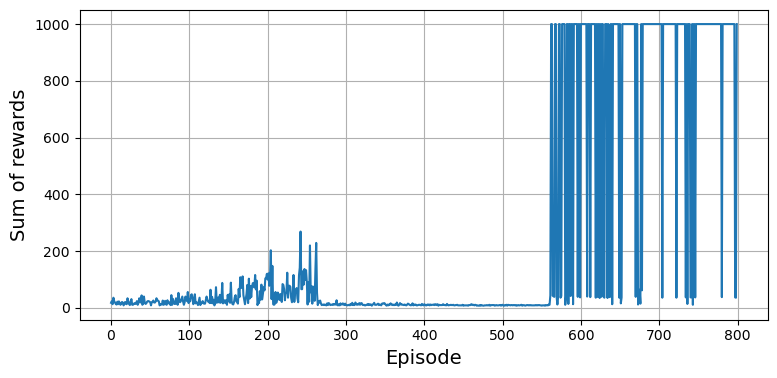

In [51]:
# extra code – this cell generates Figure 19–10
plt.figure(figsize=(8, 4))
plt.plot(totals)
plt.xlabel("Episode", fontsize=14)
plt.ylabel("Sum of rewards", fontsize=14)
plt.grid(True)

plt.show()

In [52]:
# extra code – shows an animation of the trained DQN playing one episode

torch.manual_seed(42)
dqn.eval()

def dqn_policy(obs):
    with torch.no_grad():
        return choose_dqn_action(dqn, obs)

show_one_episode(dqn_policy)

That's a very stable CartPole! 😀

# Actor-Critic

In [53]:
class ActorCritic(nn.Module):
    def __init__(self):
        super().__init__()
        self.body = nn.Sequential(nn.Linear(4, 32), nn.ReLU(),
                                  nn.Linear(32, 32), nn.ReLU())
        self.actor_head = nn.Linear(32, 1)  # outputs action logits
        self.critic_head = nn.Linear(32, 1)  # outputs state values

    def forward(self, state):
        features = self.body(state)
        return self.actor_head(features), self.critic_head(features)

In [54]:
def choose_action_and_evaluate(model, obs):
    state = torch.as_tensor(obs)
    logit, state_value = model(state)
    dist = torch.distributions.Bernoulli(logits=logit)
    action = dist.sample()
    log_prob = dist.log_prob(action)
    return int(action.item()), log_prob, state_value

In [55]:
def ac_training_step(optimizer, criterion, state_value, target_value, log_prob,
                     critic_weight):
    td_error = target_value - state_value
    actor_loss = -log_prob * td_error.detach()
    critic_loss = criterion(state_value, target_value)
    loss = actor_loss + critic_weight * critic_loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [56]:
def get_target_value(model, next_obs, reward, done, truncated, discount_factor):
    with torch.inference_mode():
        _, _, next_state_value = choose_action_and_evaluate(model, next_obs)

    running = 0.0 if (done or truncated) else 1.0
    target_value = reward + running * discount_factor * next_state_value
    return target_value

In [57]:
def run_episode_and_train(model, optimizer, criterion, env, discount_factor,
                          critic_weight, seed=None):
    obs, _info = env.reset(seed=seed)
    total_rewards = 0    
    while True:
        action, log_prob, state_value = choose_action_and_evaluate(model, obs)
        next_obs, reward, done, truncated, _info = env.step(action)
        target_value = get_target_value(model, next_obs, reward, done,
                                        truncated, discount_factor)
        ac_training_step(optimizer, criterion, state_value, target_value,
                         log_prob, critic_weight)
        total_rewards += reward
        if done or truncated:
            return total_rewards
        obs = next_obs

In [58]:
def train_actor_critic(model, optimizer, criterion, env, n_episodes=400,
                       discount_factor=0.95, critic_weight=0.3):
    totals = []
    model.train()
    for episode in range(n_episodes):
        seed = torch.randint(0, 2**32, size=()).item()
        total_rewards = run_episode_and_train(model, optimizer, criterion, env,
                                              discount_factor, critic_weight,
                                              seed=seed)
        totals.append(total_rewards)
        print(f"\rEpisode: {episode + 1}, Rewards: {total_rewards}", end=" ")

    return totals

In [59]:
torch.manual_seed(42)
ac_model = ActorCritic()
optimizer = torch.optim.NAdam(ac_model.parameters(), lr=1.1e-3)
criterion = nn.MSELoss()
totals = train_actor_critic(ac_model, optimizer, criterion, env)

Episode: 400, Rewards: 1000.0 

In [60]:
# extra code – shows an animation of the trained DQN playing one episode

torch.manual_seed(42)
ac_model.eval()

def actor_critic_policy(obs):
    with torch.no_grad():
        action, _, _ = choose_action_and_evaluate(ac_model, obs)
        return action

show_one_episode(actor_critic_policy)

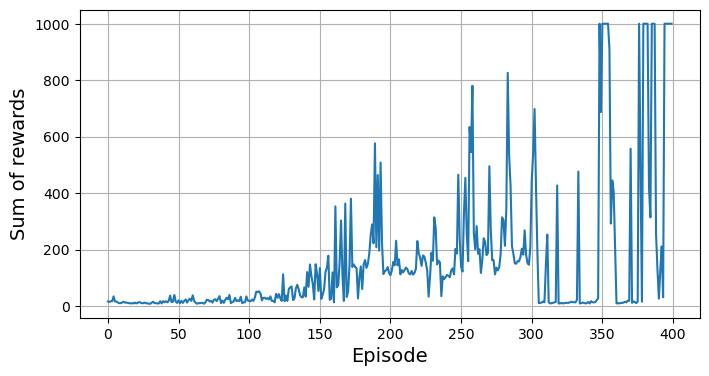

In [61]:
# extra code

plt.figure(figsize=(8, 4))
plt.plot(totals)
plt.xlabel("Episode", fontsize=14)
plt.ylabel("Sum of rewards", fontsize=14)
plt.grid(True)
plt.show()

# PPO

In [62]:
import ale_py

ale = ale_py.ALEInterface()

A.L.E: Arcade Learning Environment (version 0.10.2+unknown)
[Powered by Stella]


If you are running this notebook on your own machine and you used Anaconda to install gymnasium-atari, then the package does _not_ include the Atari ROMs, so you must install them manually. For this, you can use the AutoROM package like this:

In [63]:
gymnasium_atari_was_installed_using_anaconda = False
if gymnasium_atari_was_installed_using_anaconda:
    %pip install -qU AutoROM
    from pathlib import Path
    from AutoROM import main as autorom
    
    autorom(accept_license=True, source_file=None,  # you accept the Atari license
            install_dir=Path(ale_py.roms.__path__[0]), quiet=False)

In [64]:
from stable_baselines3.common.env_util import make_atari_env

envs = make_atari_env("BreakoutNoFrameskip-v4", n_envs=4, seed=42)
obs = envs.reset()  # a 4 ✕ 84 ✕ 84 ✕ 1 NumPy array (note: no info dict)

A.L.E: Arcade Learning Environment (version 0.10.2+unknown)
[Powered by Stella]
Game console created:
  ROM file:  /Users/ageron/mamba/envs/homlp/lib/python3.12/site-packages/ale_py/roms/breakout.bin
  Cart Name: Breakout - Breakaway IV (1978) (Atari)
  Cart MD5:  f34f08e5eb96e500e851a80be3277a56
  Display Format:  AUTO-DETECT ==> NTSC
  ROM Size:        2048
  Bankswitch Type: AUTO-DETECT ==> 2K

Running ROM file...
Random seed is -155179565
A.L.E: Arcade Learning Environment (version 0.10.2+unknown)
[Powered by Stella]
Game console created:
  ROM file:  /Users/ageron/mamba/envs/homlp/lib/python3.12/site-packages/ale_py/roms/breakout.bin
  Cart Name: Breakout - Breakaway IV (1978) (Atari)
  Cart MD5:  f34f08e5eb96e500e851a80be3277a56
  Display Format:  AUTO-DETECT ==> NTSC
  ROM Size:        2048
  Bankswitch Type: AUTO-DETECT ==> 2K

Running ROM file...
Random seed is -1805196897
A.L.E: Arcade Learning Environment (version 0.10.2+unknown)
[Powered by Stella]
Game console created:
  R

<<18 more lines>>


  ROM Size:        2048
  Bankswitch Type: AUTO-DETECT ==> 2K

Running ROM file...
Random seed is -1625411987
Game console created:
  ROM file:  /Users/ageron/mamba/envs/homlp/lib/python3.12/site-packages/ale_py/roms/breakout.bin
  Cart Name: Breakout - Breakaway IV (1978) (Atari)
  Cart MD5:  f34f08e5eb96e500e851a80be3277a56
  Display Format:  AUTO-DETECT ==> NTSC
  ROM Size:        2048
  Bankswitch Type: AUTO-DETECT ==> 2K

Running ROM file...
Random seed is 2044548950
Game console created:
  ROM file:  /Users/ageron/mamba/envs/homlp/lib/python3.12/site-packages/ale_py/roms/breakout.bin
  Cart Name: Breakout - Breakaway IV (1978) (Atari)
  Cart MD5:  f34f08e5eb96e500e851a80be3277a56
  Display Format:  AUTO-DETECT ==> NTSC
  ROM Size:        2048
  Bankswitch Type: AUTO-DETECT ==> 2K

Running ROM file...
Random seed is -1426356153
Game console created:
  ROM file:  /Users/ageron/mamba/envs/homlp/lib/python3.12/site-packages/ale_py/roms/breakout.bin
  Cart Name: Breakout - Breakaway I

In [65]:
obs.shape

(4, 84, 84, 1)

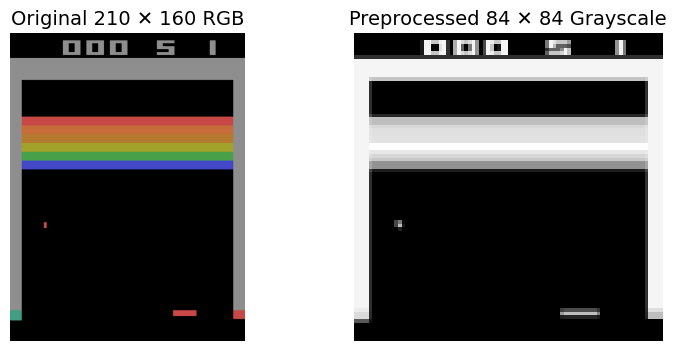

In [66]:
plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.title("Original 210 ✕ 160 RGB")
plt.imshow(envs.get_images()[0])
plt.axis("off")
plt.subplot(1, 2, 2)
plt.title("Preprocessed 84 ✕ 84 Grayscale")
plt.imshow(obs[0, :, :, 0], cmap="gray")
plt.axis("off")
plt.show()

In [67]:
from stable_baselines3.common.vec_env import VecFrameStack

envs_stacked = VecFrameStack(envs, n_stack=4)
obs = envs_stacked.reset()  # returns a 4 ✕ 84 ✕ 84 ✕ 4 NumPy array

In [68]:
from stable_baselines3 import PPO

tensorboard_logdir = "my_ppo_breakout_tensorboard"  # path to the log directory

ppo_model = PPO("CnnPolicy", envs_stacked, device=device, learning_rate=2.5e-4,
                batch_size=256, n_steps=256, n_epochs=4, clip_range=0.1,
                vf_coef=0.5, ent_coef=0.01, gamma=0.99, verbose=0,
                tensorboard_log=tensorboard_logdir)

In [69]:
ppo_model.policy

ActorCriticCnnPolicy(
  (features_extractor): NatureCNN(
    (cnn): Sequential(
      (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
      (3): ReLU()
      (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
      (5): ReLU()
      (6): Flatten(start_dim=1, end_dim=-1)
    )
    (linear): Sequential(
      (0): Linear(in_features=3136, out_features=512, bias=True)
      (1): ReLU()
    )
  )
  (pi_features_extractor): NatureCNN(
    (cnn): Sequential(
      (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
      (3): ReLU()
      (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
      (5): ReLU()
      (6): Flatten(start_dim=1, end_dim=-1)
    )
    (linear): Sequential(
      (0): Linear(in_features=3136, out_features=512, bias=True)
      (1): ReLU()
    )
  )
  (vf_features_extractor): NatureCNN(
    (cnn): 

In [70]:
%tensorboard --logdir={tensorboard_logdir} --port 6006

In [71]:
from stable_baselines3.common.callbacks import CheckpointCallback

cb = CheckpointCallback(save_freq=100_000, save_path="my_checkpoints",
                        name_prefix="breakout")
ppo_model.learn(total_timesteps=200_000, progress_bar=True, callback=cb)
ppo_model.save("my_ppo_agent_breakout")  # save the final model

Output()

I ran this code for 30 million steps so you won't have to: just run the following cell to download the trained model.

In [72]:
import urllib.request

data_root = "https://raw.githubusercontent.com/ageron/data/refs/heads/main"
filename = "ppo_agent_breakout.zip"
urllib.request.urlretrieve(f"{data_root}/{filename}", f"my_{filename}")

('my_ppo_agent_breakout.zip', <http.client.HTTPMessage at 0x3fc01b5f0>)

In [73]:
ppo_model = PPO.load("my_ppo_agent_breakout")  # or load the best checkpoint
eval_env = make_atari_env("BreakoutNoFrameskip-v4", n_envs=1, seed=42)
eval_stacked = VecFrameStack(eval_env, n_stack=4)
frames = []
obs = eval_stacked.reset()
for _ in range(5000):  # some limit in case the agent never loses
    frames.append(eval_stacked.render())
    action, _ = ppo_model.predict(obs, deterministic=True) # for reproducibility
    obs, reward, done, info = eval_stacked.step(action)
    if done[0]:  # note: there's no `truncated`
        break

eval_stacked.close()

A.L.E: Arcade Learning Environment (version 0.10.2+unknown)
[Powered by Stella]
Game console created:
  ROM file:  /Users/ageron/mamba/envs/homlp/lib/python3.12/site-packages/ale_py/roms/breakout.bin
  Cart Name: Breakout - Breakaway IV (1978) (Atari)
  Cart MD5:  f34f08e5eb96e500e851a80be3277a56
  Display Format:  AUTO-DETECT ==> NTSC
  ROM Size:        2048
  Bankswitch Type: AUTO-DETECT ==> 2K

Running ROM file...
Random seed is -393043141
Game console created:
  ROM file:  /Users/ageron/mamba/envs/homlp/lib/python3.12/site-packages/ale_py/roms/breakout.bin
  Cart Name: Breakout - Breakaway IV (1978) (Atari)
  Cart MD5:  f34f08e5eb96e500e851a80be3277a56
  Display Format:  AUTO-DETECT ==> NTSC
  ROM Size:        2048
  Bankswitch Type: AUTO-DETECT ==> 2K

Running ROM file...
Random seed is -1625411987


In [74]:
plot_animation(frames)

Note: I also trained an agent for the Centipede game: to try it out, replace "breakout" (or "Breakout") with "centipede" (or "Centipede") in the last three cells and run them.

I hope you enjoyed this notebook!